# New viz for the top 10 features

In [1]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
final_df=pd.read_csv('/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/final_cleaned_zscored_features_COMBINED.csv')

In [3]:
# ── Load top 10 features ──────────────────────────────────────────────────────
top10 = pd.read_csv(
    '/Users/gracieshao/Desktop/ALS T1s/Scripts/top10_ttest_uncorrelated_roi_features_combined.csv')
top10_cols = (top10['roi'] + '__' + top10['feature']).tolist()
print(f"Features loaded: {len(top10_cols)}")

# ── Parse metadata from INFO_PatientName ──────────────────────────────────────
parts = final_df['INFO_PatientName'].str.split('_')
final_df['SubjectID'] = parts.str[2]
final_df['Visit']     = parts.str.get(4)
final_df['Group']     = final_df['SubjectID'].str[0].map({'P': 'Patient', 'C': 'Control'})

Features loaded: 10


In [4]:
# ── Build patient V1 wide matrix ──────────────────────────────────────────────
v1_pat = final_df[
    (final_df['Visit'] == 'V1') &
    (final_df['Group'] == 'Patient')
].copy()

FEAT_COLS_ALL = [c for c in v1_pat.columns
                 if c not in ['INFO_PatientName', 'INFO_NameOfRoi',
                               'SubjectID', 'Visit', 'Group']]

wide_pat = v1_pat.pivot_table(
    index   = 'INFO_PatientName',
    columns = 'INFO_NameOfRoi',
    values  = FEAT_COLS_ALL,
    aggfunc = 'first'
)
wide_pat.columns = [f"{roi}__{feat}" for feat, roi in wide_pat.columns]
wide_pat = wide_pat.reset_index()

# ── Validate columns ──────────────────────────────────────────────────────────
missing = [c for c in top10_cols if c not in wide_pat.columns]
if missing:
    print(f"WARNING — missing: {missing}")
top10_cols = [c for c in top10_cols if c in wide_pat.columns]

X_scaled = StandardScaler().fit_transform(wide_pat[top10_cols].values)
print(f"Patient matrix: {X_scaled.shape}  |  NaNs: {np.isnan(X_scaled).sum()}")

Patient matrix: (251, 10)  |  NaNs: 0


In [5]:
# ── Find which subject / feature contains the NaN ────────────────────────────
X_check = wide_pat[top10_cols].copy()

# Which columns have NaN
nan_cols = X_check.columns[X_check.isna().any()].tolist()
print(f"Columns with NaN: {nan_cols}")

# Which rows have NaN
nan_row_mask = X_check.isna().any(axis=1)
print(f"\nSubjects with NaN:")
print(wide_pat.loc[nan_row_mask, ['INFO_PatientName'] + nan_cols].to_string(index=False))

Columns with NaN: []

Subjects with NaN:
Empty DataFrame
Columns: [INFO_PatientName]
Index: []


In [6]:
# ── Embeddings ────────────────────────────────────────────────────────────────
print("Computing t-SNE...")
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
print("Computing UMAP...")
umap_emb = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

# ── Cluster validity sweep k=1–8 ─────────────────────────────────────────────
# Silhouette and Davies-Bouldin require k >= 2; k=1 is skipped for metrics
K_RANGE     = range(1, 9)
K_METRIC    = range(2, 9)   # valid range for silhouette / DB
metrics = {'silhouette': {}, 'davies_bouldin': {}}

for k in K_METRIC:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    metrics['silhouette'][k]     = silhouette_score(X_scaled, labels)
    metrics['davies_bouldin'][k] = davies_bouldin_score(X_scaled, labels)

ks   = list(K_RANGE)
sils = [metrics['silhouette'].get(k, np.nan) for k in ks]
dbs  = [metrics['davies_bouldin'].get(k, np.nan) for k in ks]
best_sil = max(metrics['silhouette'], key=metrics['silhouette'].get)
best_db  = min(metrics['davies_bouldin'], key=metrics['davies_bouldin'].get)

print(f"\nSilhouette best k={best_sil}  ({metrics['silhouette'][best_sil]:.4f})")
print(f"Davies-Bouldin best k={best_db}  ({metrics['davies_bouldin'][best_db]:.4f})")
print("\nFull scores:")
for k in K_METRIC:
    print(f"  k={k}  sil={metrics['silhouette'][k]:.4f}  DB={metrics['davies_bouldin'][k]:.4f}")


Computing t-SNE...
Computing UMAP...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Silhouette best k=3  (0.3805)
Davies-Bouldin best k=2  (1.1499)

Full scores:
  k=2  sil=0.3748  DB=1.1499
  k=3  sil=0.3805  DB=1.1840
  k=4  sil=0.2811  DB=1.4864
  k=5  sil=0.2767  DB=1.5094
  k=6  sil=0.2598  DB=1.5415
  k=7  sil=0.2054  DB=1.4530
  k=8  sil=0.1950  DB=1.4782


In [7]:
# ── KMeans for k=3 and k=4 ────────────────────────────────────────────────────
km_labels = {
    k: KMeans(n_clusters=k, random_state=42, n_init=10)
       .fit_predict(X_scaled).astype(str)
    for k in [3, 4]
}
PALETTES = {
    3: ['#E41A1C', '#377EB8', '#4DAF4A'],
    4: ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']
}


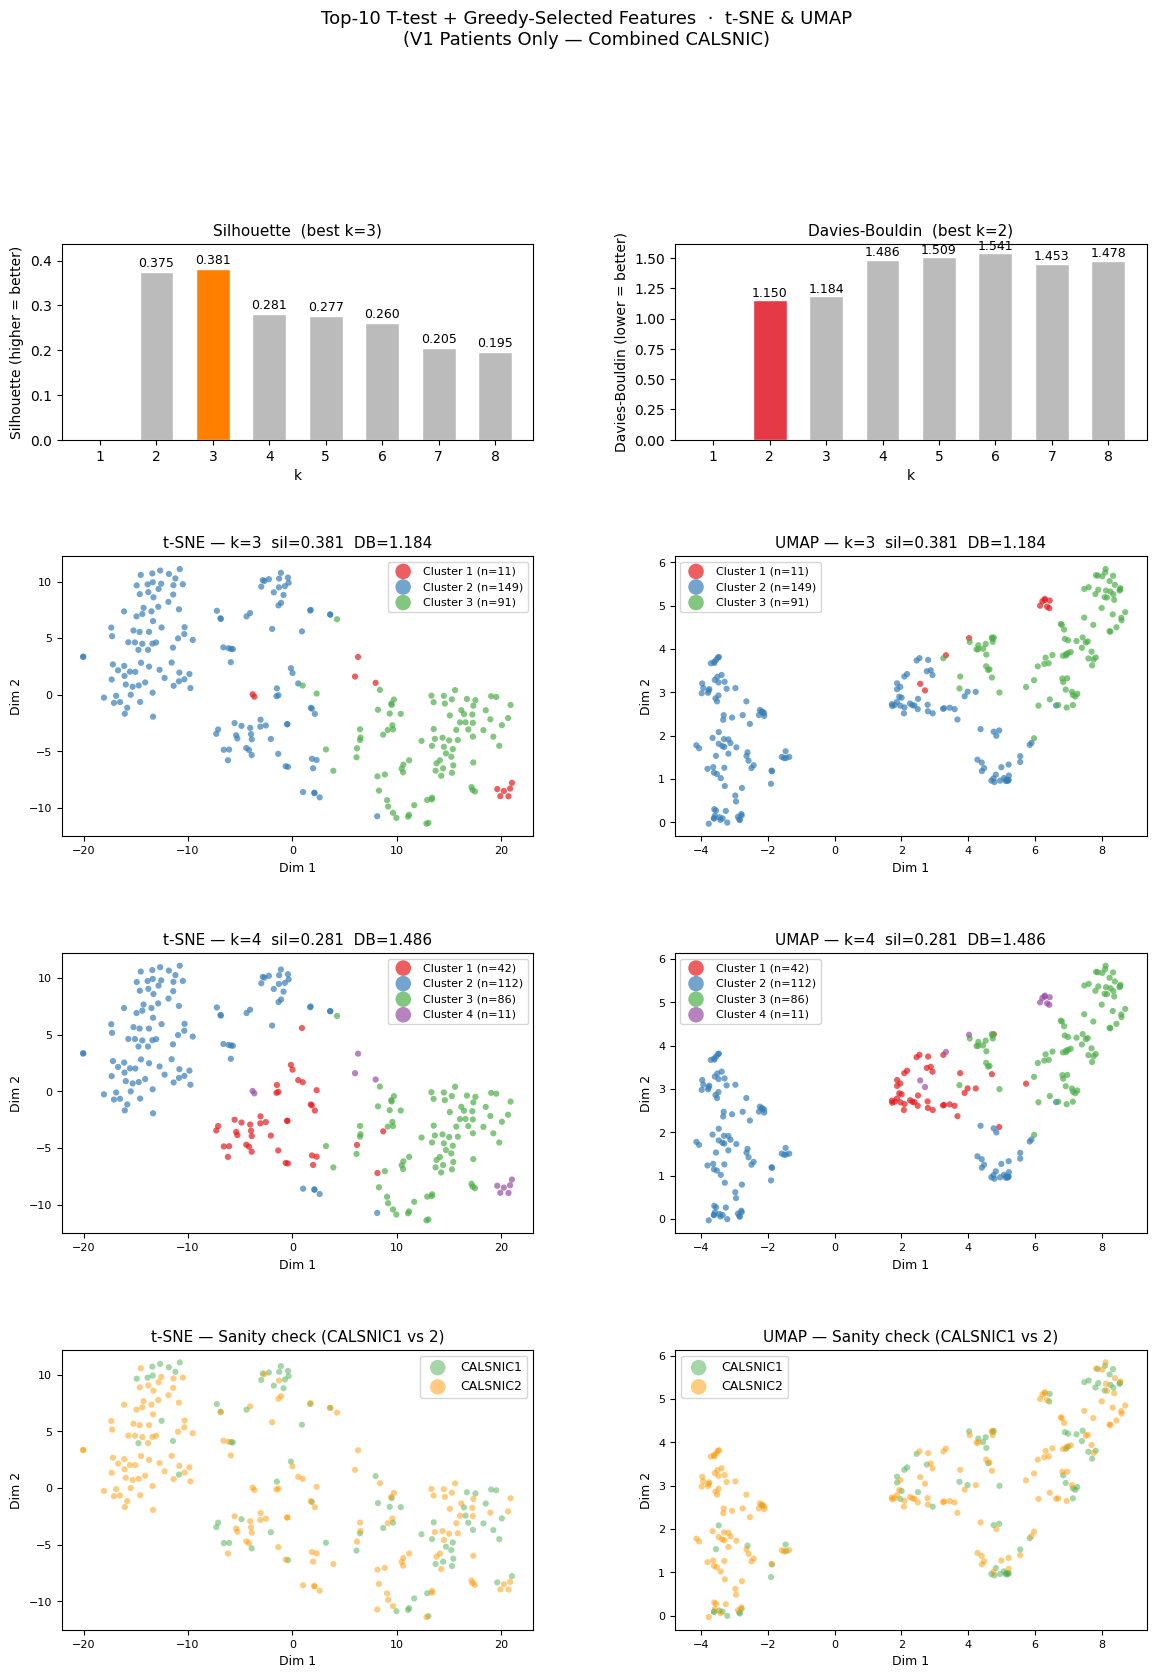

Saved.


In [8]:
# ── Figure: 4 rows ────────────────────────────────────────────────────────────
study_lbls = wide_pat['INFO_PatientName'].str.split('_').str[0].values

fig = plt.figure(figsize=(14, 18))
gs  = fig.add_gridspec(4, 2, hspace=0.45, wspace=0.3,
                        height_ratios=[0.7, 1, 1, 1])

# Row 0: validity metrics
ax_sil = fig.add_subplot(gs[0, 0])
bar_c  = ['#FF7F00' if k == best_sil else '#BBBBBB' for k in ks]
valid_sils = [s for s in sils if not np.isnan(s)]
ax_sil.bar(ks, [s if not np.isnan(s) else 0 for s in sils],
           color=bar_c, edgecolor='white', width=0.6)
for k, s in zip(ks, sils):
    if not np.isnan(s):
        ax_sil.text(k, s + 0.005, f'{s:.3f}', ha='center', va='bottom', fontsize=9)
ax_sil.set_xticks(ks)
ax_sil.set_xlabel('k'); ax_sil.set_ylabel('Silhouette (higher = better)')
ax_sil.set_title(f'Silhouette  (best k={best_sil})', fontsize=11)
ax_sil.set_ylim(0, max(valid_sils) * 1.15)

ax_db = fig.add_subplot(gs[0, 1])
bar_c2 = ['#E63946' if k == best_db else '#BBBBBB' for k in ks]
valid_dbs = [d for d in dbs if not np.isnan(d)]
ax_db.bar(ks, [d if not np.isnan(d) else 0 for d in dbs],
          color=bar_c2, edgecolor='white', width=0.6)
for k, d in zip(ks, dbs):
    if not np.isnan(d):
        ax_db.text(k, d + 0.005, f'{d:.3f}', ha='center', va='bottom', fontsize=9)
ax_db.set_xticks(ks)
ax_db.set_xlabel('k'); ax_db.set_ylabel('Davies-Bouldin (lower = better)')
ax_db.set_title(f'Davies-Bouldin  (best k={best_db})', fontsize=11)

# Rows 1–2: t-SNE and UMAP coloured by cluster
for row_idx, k in enumerate([3, 4]):
    labels = km_labels[k]
    colors = PALETTES[k]
    for col_idx, (emb, title) in enumerate(
            zip([tsne_emb, umap_emb], ['t-SNE', 'UMAP'])):
        ax = fig.add_subplot(gs[row_idx + 1, col_idx])
        for cl, color in zip(sorted(set(labels), key=int), colors):
            mask = labels == cl
            ax.scatter(emb[mask, 0], emb[mask, 1], c=[color],
                       alpha=0.7, s=20, edgecolors='none',
                       label=f'Cluster {int(cl)+1} (n={mask.sum()})')
        ax.set_title(f'{title} — k={k}  sil={metrics["silhouette"][k]:.3f}  '
                     f'DB={metrics["davies_bouldin"][k]:.3f}', fontsize=11)
        ax.set_xlabel('Dim 1', fontsize=9); ax.set_ylabel('Dim 2', fontsize=9)
        ax.legend(markerscale=2.5, fontsize=8, loc='best')
        ax.tick_params(labelsize=8)

# Row 3: sanity check — colour by study
study_palette = {'CALSNIC1': '#4CAF50', 'CALSNIC2': '#FF9800'}
for col_idx, (emb, title) in enumerate(
        zip([tsne_emb, umap_emb], ['t-SNE', 'UMAP'])):
    ax = fig.add_subplot(gs[3, col_idx])
    for study, color in study_palette.items():
        mask = study_lbls == study
        ax.scatter(emb[mask, 0], emb[mask, 1], c=[color],
                   alpha=0.5, s=20, edgecolors='none', label=study)
    ax.set_title(f'{title} — Sanity check (CALSNIC1 vs 2)', fontsize=11)
    ax.set_xlabel('Dim 1', fontsize=9); ax.set_ylabel('Dim 2', fontsize=9)
    ax.legend(markerscale=2.5, fontsize=9, loc='best')
    ax.tick_params(labelsize=8)

fig.suptitle(
    'Top-10 T-test + Greedy-Selected Features  ·  t-SNE & UMAP\n'
    '(V1 Patients Only — Combined CALSNIC)',
    fontsize=13, y=1.01)

plt.savefig(
    '/Users/gracieshao/Desktop/ALS T1s/data/preprocessed/'
    'tsne_umap_top10_ttest_COMBINED.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")
